In [3]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam

print("Libraries imported successfully")
print("TensorFlow version:", tf.__version__)

2026-06-28 17:25:19.954374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782667520.192968      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782667520.259258      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782667520.828941      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782667520.829022      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782667520.829026      58 computation_placer.cc:177] computation placer alr

Libraries imported successfully
TensorFlow version: 2.19.0


In [4]:

image_paths = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))
print(image_paths[:10])

if len(image_paths) < 100:
    raise Exception("Not enough images. You need the actual dataset, not only a notebook.")

Total images found: 8457
['/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-2146-_jpg.rf.01a89d5d82227ffcef31965aef1b4515.jpg', '/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-1727-_jpg.rf.760fe36d789dae0cefa6ce2b9fac8fab.jpg', '/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-48-_png.rf.1cef011b6849d3453b3fdd646a555819.jpg', '/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-1977-_jpg.rf.ae2f064d27b905e0c0e6f62c76cf487e.jpg', '/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-1888-_jpg.rf.a02486749f0c9208dc2256ac7f5ff1f8.jpg', '/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-1337-_jpg.rf.2e24d381f5841931cfa6125d27e53fad.jpg', '/kaggle/input/datasets/ayesha19765/damaged-package-detection/dataset/damaged/cardboard-337-_png.rf.935afd43cac93785d7e45617ecc95854.jpg

In [5]:


filepaths = []
labels = []

for path in image_paths:
    folder = os.path.basename(os.path.dirname(path)).lower()
    
    if "damage" in folder or "defect" in folder or "bad" in folder:
        label = "Damaged"
    elif "intact" in folder or "normal" in folder or "good" in folder or "undamaged" in folder:
        label = "Undamaged"
    else:
        continue

    filepaths.append(path)
    labels.append(label)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print(df.head())
print("Total usable images:", len(df))
print(df["label"].value_counts())

if len(df) < 100:
    raise Exception("Labels were not detected from folder names. Send me the folder structure.")



                                            filepath    label
0  /kaggle/input/datasets/ayesha19765/damaged-pac...  Damaged
1  /kaggle/input/datasets/ayesha19765/damaged-pac...  Damaged
2  /kaggle/input/datasets/ayesha19765/damaged-pac...  Damaged
3  /kaggle/input/datasets/ayesha19765/damaged-pac...  Damaged
4  /kaggle/input/datasets/ayesha19765/damaged-pac...  Damaged
Total usable images: 8457
label
Damaged      6462
Undamaged    1995
Name: count, dtype: int64


In [6]:


from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print(train_df["label"].value_counts())

Train: 5919
Validation: 1269
Test: 1269
label
Damaged      4523
Undamaged    1396
Name: count, dtype: int64


In [7]:


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_gen.class_indices)
class_names = list(train_gen.class_indices.keys())

print("Classes:", class_names)

Found 5919 validated image filenames belonging to 2 classes.
Found 1269 validated image filenames belonging to 2 classes.
Found 1269 validated image filenames belonging to 2 classes.
Classes: ['Damaged', 'Undamaged']


In [8]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

cnn_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782667553.740316      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:


history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10


I0000 00:00:1782667558.891706     128 service.cc:152] XLA service 0x78cf84004910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782667558.891755     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782667559.285234     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/185 ━━━━━━━━━━━━━━━━━━━━ 21:46 7s/step - accuracy: 0.5312 - loss: 0.6884

I0000 00:00:1782667563.758389     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 32/185 ━━━━━━━━━━━━━━━━━━━━ 1:34 616ms/step - accuracy: 0.7543 - loss: 0.5622

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


185/185 ━━━━━━━━━━━━━━━━━━━━ 149s 771ms/step - accuracy: 0.7739 - loss: 0.4794 - val_accuracy: 0.8117 - val_loss: 0.4084
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 78s 424ms/step - accuracy: 0.7949 - loss: 0.4187 - val_accuracy: 0.8211 - val_loss: 0.3987
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 78s 423ms/step - accuracy: 0.8057 - loss: 0.4037 - val_accuracy: 0.8385 - val_loss: 0.3643
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 78s 420ms/step - accuracy: 0.8062 - loss: 0.3896 - val_accuracy: 0.8345 - val_loss: 0.3712
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 418ms/step - accuracy: 0.8179 - loss: 0.3845 - val_accuracy: 0.8463 - val_loss: 0.3561
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 83s 448ms/step - accuracy: 0.8246 - loss: 0.3708 - val_accuracy: 0.8526 - val_loss: 0.3527
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 86s 465ms/step - accuracy: 0.8339 - loss: 0.3675 - val_accuracy: 0.8471 - val_loss: 0.3421
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 78s 420ms/step - accuracy: 0.8390 - loss: 0.3591 - va

In [10]:


import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = cnn_model.evaluate(test_gen)
print("Custom CNN Test Accuracy:", test_acc)

y_true = test_gen.classes
y_pred_probs = cnn_model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 649ms/step - accuracy: 0.8519 - loss: 0.3541
Custom CNN Test Accuracy: 0.8518518805503845
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step
              precision    recall  f1-score   support

     Damaged       0.89      0.92      0.90       969
   Undamaged       0.71      0.63      0.67       300

    accuracy                           0.85      1269
   macro avg       0.80      0.78      0.79      1269
weighted avg       0.85      0.85      0.85      1269



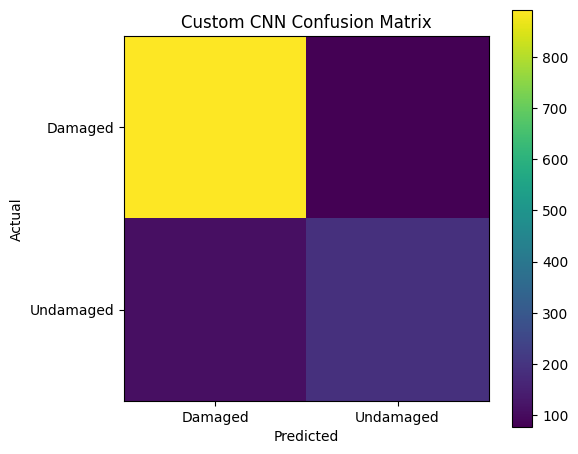

In [11]:


import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Custom CNN Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(num_classes), class_names)
plt.yticks(np.arange(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

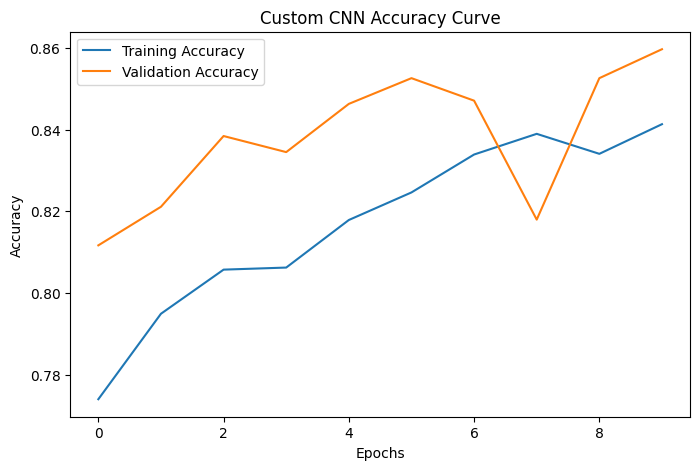

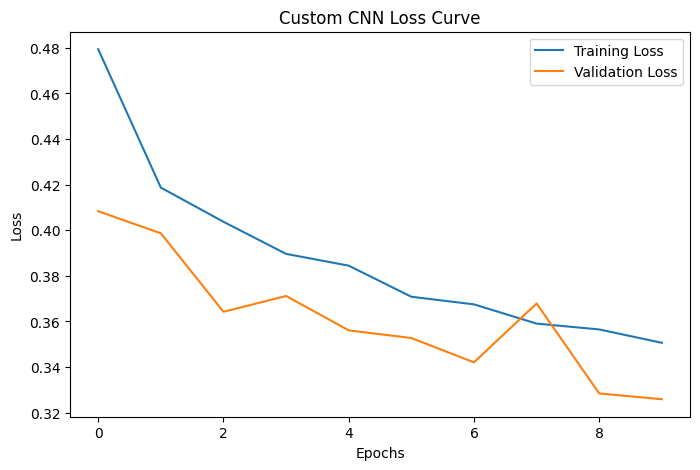

In [12]:


plt.figure(figsize=(8,5))
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation="softmax")(x)

mobile_model = Model(inputs=base_model.input, outputs=output)

mobile_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobile_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:


history_mobile = mobile_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
 29/185 ━━━━━━━━━━━━━━━━━━━━ 1:00 387ms/step - accuracy: 0.6271 - loss: 0.7562

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


185/185 ━━━━━━━━━━━━━━━━━━━━ 107s 512ms/step - accuracy: 0.7829 - loss: 0.4801 - val_accuracy: 0.8306 - val_loss: 0.3757
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 414ms/step - accuracy: 0.8307 - loss: 0.3763 - val_accuracy: 0.8463 - val_loss: 0.3419
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 417ms/step - accuracy: 0.8488 - loss: 0.3447 - val_accuracy: 0.8526 - val_loss: 0.3278
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 417ms/step - accuracy: 0.8576 - loss: 0.3231 - val_accuracy: 0.8660 - val_loss: 0.3158
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 76s 412ms/step - accuracy: 0.8692 - loss: 0.3069 - val_accuracy: 0.8589 - val_loss: 0.3118
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 418ms/step - accuracy: 0.8773 - loss: 0.2910 - val_accuracy: 0.8621 - val_loss: 0.3088
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 76s 412ms/step - accuracy: 0.8777 - loss: 0.2881 - val_accuracy: 0.8747 - val_loss: 0.2943
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 417ms/step - accuracy: 0.8794 - loss: 0.2802 - va

In [15]:


mobile_loss, mobile_acc = mobile_model.evaluate(test_gen)
print("MobileNetV2 Test Accuracy:", mobile_acc)

y_pred_probs_mobile = mobile_model.predict(test_gen)
y_pred_mobile = np.argmax(y_pred_probs_mobile, axis=1)

print(classification_report(y_true, y_pred_mobile, target_names=class_names))

40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 326ms/step - accuracy: 0.8818 - loss: 0.2816
MobileNetV2 Test Accuracy: 0.8817967176437378
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step
              precision    recall  f1-score   support

     Damaged       0.94      0.90      0.92       969
   Undamaged       0.72      0.81      0.76       300

    accuracy                           0.88      1269
   macro avg       0.83      0.86      0.84      1269
weighted avg       0.89      0.88      0.88      1269



         Model  Test Accuracy
0   Custom CNN       0.851852
1  MobileNetV2       0.881797


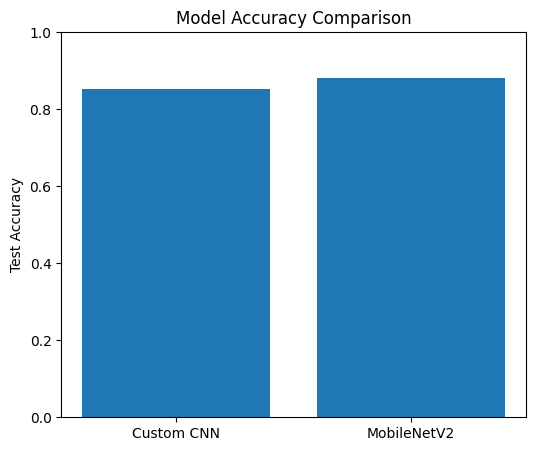

In [16]:


import pandas as pd

results = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [test_acc, mobile_acc]
})

print(results)

plt.figure(figsize=(6,5))
plt.bar(results["Model"], results["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

In [19]:


cnn_model.save("custom_cnn_package_damage.h5")
mobile_model.save("mobilenetv2_package_damage.h5")

print("Models saved successfully")

Models saved successfully


In [20]:
import os
import shutil
from IPython.display import FileLink

OUTPUT_DIR = "/kaggle/working/project_outputs"
ZIP_NAME = "/kaggle/working/Packaging_Damage_Project.zip"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save available DataFrames if they exist
for name in [
    "df",
    "train_df",
    "val_df",
    "test_df",
    "results"
]:
    if name in globals():
        globals()[name].to_csv(f"{OUTPUT_DIR}/{name}.csv", index=False)

# Save classification reports if available
try:
    import pandas as pd
    from sklearn.metrics import classification_report

    if all(x in globals() for x in ["y_true", "y_pred", "class_names"]):
        report = classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            output_dict=True
        )
        pd.DataFrame(report).transpose().to_csv(
            f"{OUTPUT_DIR}/cnn_classification_report.csv"
        )

    if all(x in globals() for x in ["y_true", "y_pred_mobile", "class_names"]):
        report = classification_report(
            y_true,
            y_pred_mobile,
            target_names=class_names,
            output_dict=True
        )
        pd.DataFrame(report).transpose().to_csv(
            f"{OUTPUT_DIR}/mobilenet_classification_report.csv"
        )
except:
    pass

# Copy all PNG/JPG files generated in working directory
for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".csv")):
            src = os.path.join(root, file)
            dst = os.path.join(OUTPUT_DIR, file)

            if src != dst:
                try:
                    shutil.copy2(src, dst)
                except:
                    pass

# Create ZIP
shutil.make_archive(
    ZIP_NAME.replace(".zip", ""),
    "zip",
    OUTPUT_DIR
)

print("ZIP created successfully:")
print(ZIP_NAME)

FileLink(ZIP_NAME)

ZIP created successfully:
/kaggle/working/Packaging_Damage_Project.zip


/kaggle/working/Packaging_Damage_Project.zip

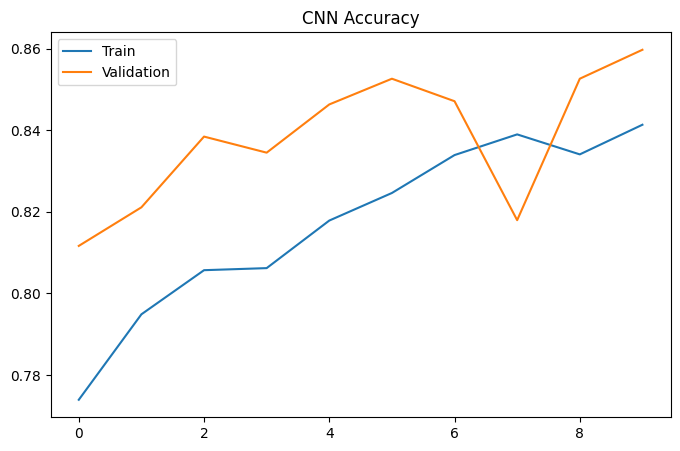

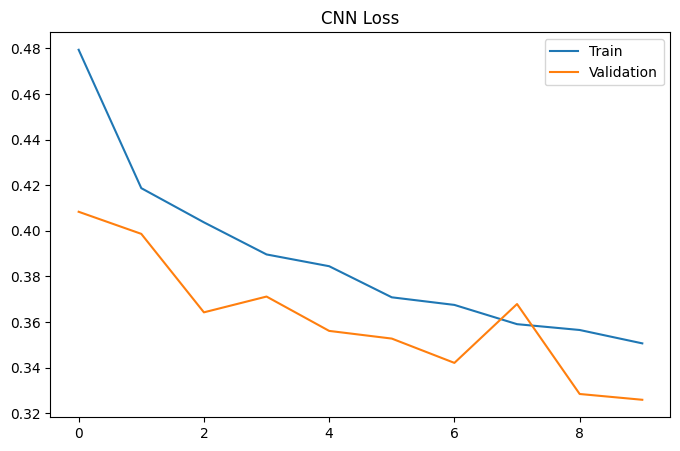

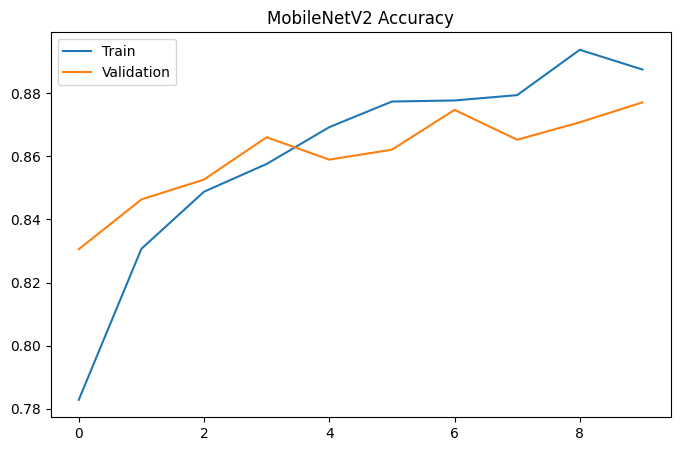

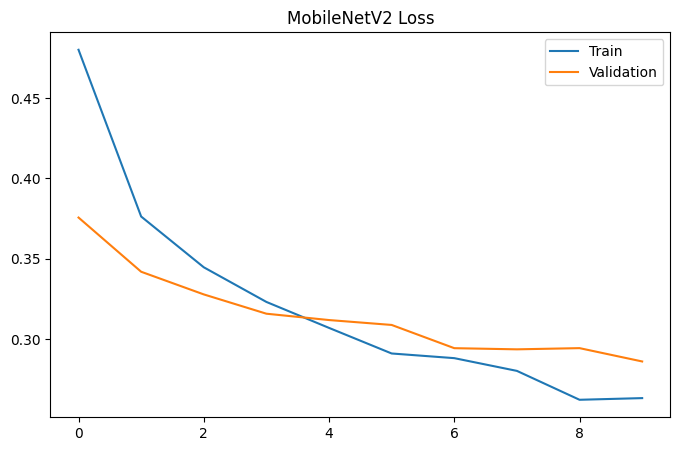

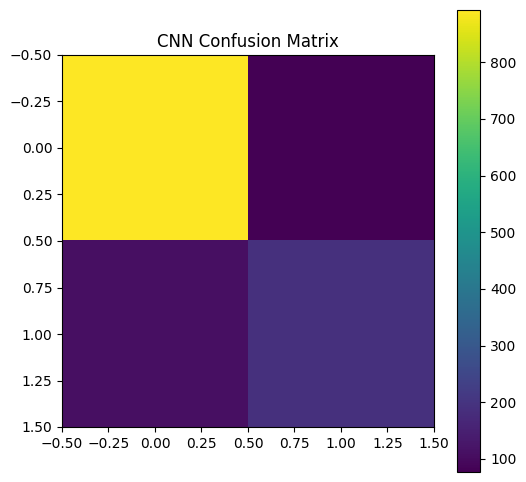

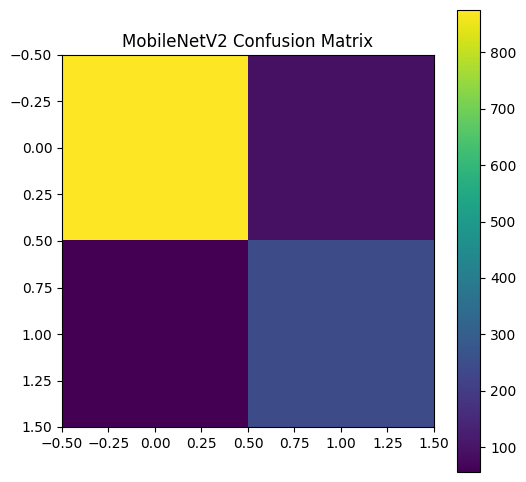

All images saved


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# CNN Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('CNN Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('/kaggle/working/project_outputs/cnn_accuracy.png')
plt.show()

# CNN Loss
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('CNN Loss')
plt.legend(['Train','Validation'])
plt.savefig('/kaggle/working/project_outputs/cnn_loss.png')
plt.show()

# MobileNet Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('/kaggle/working/project_outputs/mobilenet_accuracy.png')
plt.show()

# MobileNet Loss
plt.figure(figsize=(8,5))
plt.plot(history_mobile.history['loss'])
plt.plot(history_mobile.history['val_loss'])
plt.title('MobileNetV2 Loss')
plt.legend(['Train','Validation'])
plt.savefig('/kaggle/working/project_outputs/mobilenet_loss.png')
plt.show()

# CNN Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.colorbar()
plt.title("CNN Confusion Matrix")
plt.savefig('/kaggle/working/project_outputs/cnn_confusion_matrix.png')
plt.show()

# MobileNet Confusion Matrix
cm2 = confusion_matrix(y_true, y_pred_mobile)

plt.figure(figsize=(6,6))
plt.imshow(cm2)
plt.colorbar()
plt.title("MobileNetV2 Confusion Matrix")
plt.savefig('/kaggle/working/project_outputs/mobilenet_confusion_matrix.png')
plt.show()

print("All images saved")

In [23]:
import shutil

shutil.make_archive(
    "/kaggle/working/Packaging_Damage_Project_Final",
    "zip",
    "/kaggle/working/project_outputs"
)

print("Final ZIP created")

Final ZIP created


In [24]:
print("CNN Accuracy:", test_acc)
print("MobileNetV2 Accuracy:", mobile_acc)

CNN Accuracy: 0.8518518805503845
MobileNetV2 Accuracy: 0.8817967176437378
